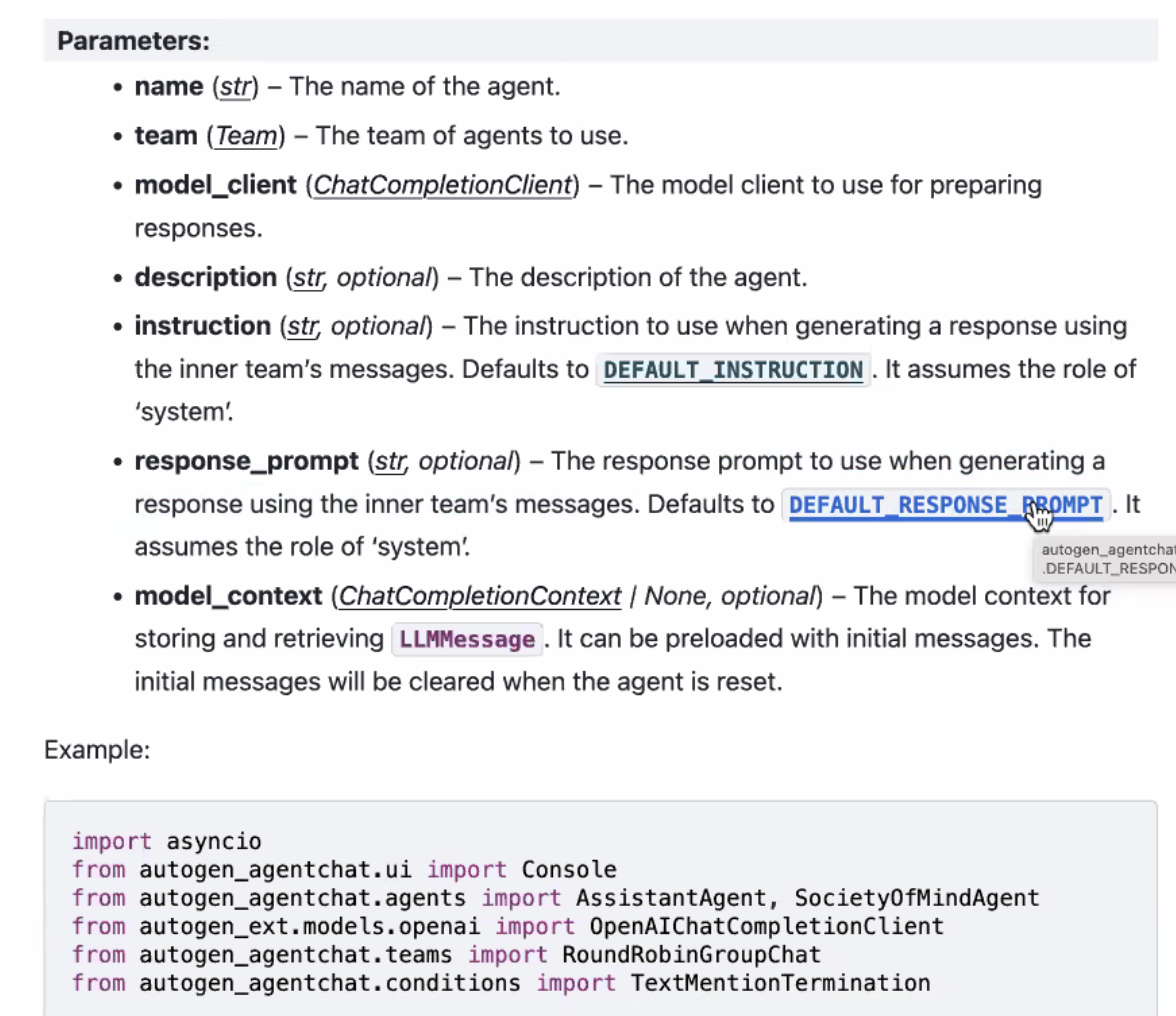

In [3]:
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import TextMessage
from autogen_core import CancellationToken
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.tools.http import HttpTool
from autogen_core.models import UserMessage
from autogen_ext.models.ollama import OllamaChatCompletionClient
from typing import Any, Dict, List

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import HandoffTermination, TextMentionTermination
from autogen_agentchat.messages import HandoffMessage
from autogen_agentchat.teams import Swarm
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient

In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
import json
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
open_router_api_key= os.getenv("OPENROUTER_API_KEY")

In [4]:

model=ChatGroq(model="qwen-qwq-32B")
def llm(input):
    model=ChatGroq(model="qwen-qwq-32B")
    output=model.invoke(input)
    return output.content
print(model)

#model1=OpenAIChatCompletionClient(model="gpt-4o")
#print(model1)

client=<groq.resources.chat.completions.Completions object at 0x10e9d3f50> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f8cdca0> model_name='qwen-qwq-32B' model_kwargs={} groq_api_key=SecretStr('**********')


In [5]:

open_router_model_client = OpenAIChatCompletionClient(
    base_url="https://openrouter.ai/api/v1",
    model="nvidia/llama-3.1-nemotron-70b-instruct",
    api_key=open_router_api_key,
    model_info={
        "family": 'deepseek',
        "vision": True,
        "function_calling": True,
        "json_output": False
    }
)

/Users/arunkumar/anaconda3/envs/py312/lib/python3.12/site-packages/autogen_ext/models/openai/_openai_client.py:439: UserWarning: Missing required field 'structured_output' in ModelInfo. This field will be required in a future version of AutoGen.
  validate_model_info(self._model_info)


Society of Minds is like Teams of Teams ,Inner Teams, Outer Teams, and we can acheive Langchain,Langgraph flows

In [12]:

import asyncio
from autogen_agentchat.ui import Console
from autogen_agentchat.agents import AssistantAgent, SocietyOfMindAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.conditions import TextMentionTermination


async def main() -> None:
    #model_client = OpenAIChatCompletionClient(model="gpt-4o",api_key=api_key)

    agent1 = AssistantAgent("assistant1", model_client=model1, system_message="You are a writer, write well under 50 words.")
    agent2 = AssistantAgent(
        "assistant2",
        model_client=model1,
        system_message="You are an editor, provide critical feedback under 50 words. Respond with 'APPROVE' if the text addresses all feedbacks.",
    )
    inner_termination = TextMentionTermination("APPROVE")
    inner_team = RoundRobinGroupChat([agent1, agent2], termination_condition=inner_termination)


    society_of_mind_agent = SocietyOfMindAgent("society_of_mind", team=inner_team, model_client=model1,response_prompt='Output a standalone response to the original request under 50 words, without mentioning any of the intermediate discussion.')

    agent4 = society_of_mind_agent = SocietyOfMindAgent("society_of_mind", team=inner_team, model_client=model1,response_prompt='Output a standalone response to the original request under 50 words, without mentioning any of the intermediate discussion.')





    agent3 = AssistantAgent(
        "assistant3", model_client=model1, system_message="Translate the text to Spanish under 50 words."
    )
    team = RoundRobinGroupChat([society_of_mind_agent, agent3], max_turns=2)

    stream = team.run_stream(task="Write a short story with a surprising ending under 50 words.")
    await Console(stream)


await (main())

---------- TextMessage (user) ----------
Write a short story with a surprising ending under 50 words.
---------- TextMessage (assistant1) ----------
A lonely man mailed love letters to a stranger daily. One day, a reply arrived: "I'm right beside you." Jolted, he looked up, meeting the eyes of his bus stop companion. They'd never spoken, yet their silent journeys had always been shared. They smiled, bridging the space between them.
---------- TextMessage (assistant2) ----------
APPROVE
---------- TextMessage (society_of_mind) ----------
A lonely man sent daily love letters to a stranger. One unexpected day, a reply came: "I'm right beside you." He glanced up to find his bus stop companion. Their silent journeys were silently shared; they smiled and closed the gap between them.
---------- TextMessage (assistant3) ----------
Un hombre solitario enviaba cartas de amor diarias a una desconocida. Un día inesperado, llegó una respuesta: "Estoy a tu lado." Levantó la vista y encontró a su com